# EDA 1 — the corpus landscape

What is actually in the parsed corpus, before any heuristic or model touches it.
Counted from `data/local/tables/provisions.parquet`. No API calls.

The point of this page is calibration: when a later result says "provisions
with a duty and an exception behave like X", it helps to know how long a
provision is, how unevenly they are spread across documents, and how much of
the corpus is structural boilerplate.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from simulacria.pipeline.silver import POOLS
from simulacria.pipeline.store import connect

POOL = "v1"  # "v1" = the frozen 50-law corpus, "v2" = the larger pool
connection = connect(POOLS[POOL].tables_dir)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 70)


def q(sql: str) -> pd.DataFrame:
    return connection.execute(sql).df()


provisions = q("select * from provisions")
print(
    f"Pool {POOL}: {len(provisions):,} provisions from {provisions.document_id.nunique()} documents"
)

Pool v1: 1,952 provisions from 50 documents


## 1. How long is a provision?

Length matters twice over. It drives cost directly, and it is the most obvious
confounder in any lexical score: longer text has more room for markers.

,count,mean,std,min,10%,25%,50%,75%,90%,99%,max
char_count,1952.0,403.691086,366.721669,34.0,127.0,190.0,321.5,504.25,757.8,1621.23,7894.0


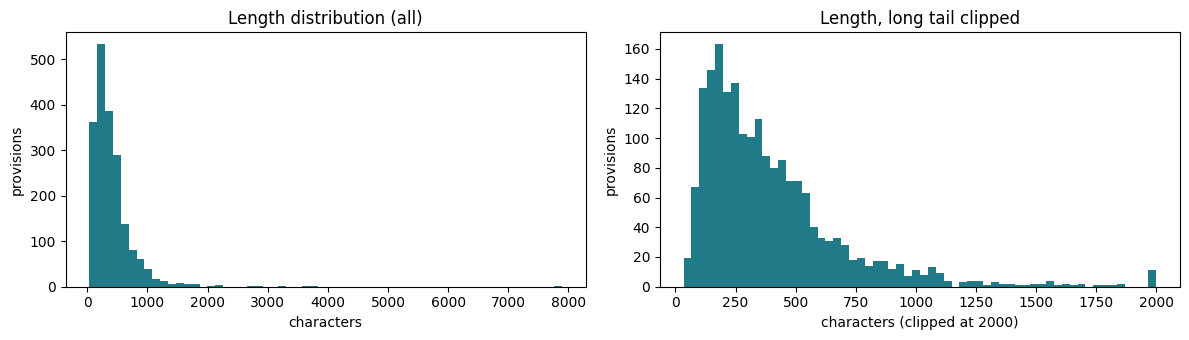

8.5% of provisions are under 120 characters — mostly headings, references and stubs.


In [2]:
display(provisions.char_count.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(provisions.char_count, bins=60, color="#207a87")
axes[0].set(xlabel="characters", ylabel="provisions", title="Length distribution (all)")
axes[1].hist(provisions.char_count.clip(upper=2000), bins=60, color="#207a87")
axes[1].set(
    xlabel="characters (clipped at 2000)", ylabel="provisions", title="Length, long tail clipped"
)
plt.tight_layout()
plt.show()

short = (provisions.char_count < 120).mean()
print(
    f"{short:.1%} of provisions are under 120 characters — mostly headings, references and stubs."
)

## 2. How evenly are provisions spread across documents?

A handful of large acts can dominate any corpus-wide statistic. This is what a
per-document weighting would have to correct for.

In [3]:
per_document = (
    provisions.groupby(["document_id", "document_title"])
    .agg(provisions=("provision_id", "count"), chars=("char_count", "sum"))
    .sort_values("provisions", ascending=False)
)
display(per_document.head(10))
display(per_document.provisions.describe().to_frame().T)

share = per_document.provisions.head(5).sum() / len(provisions)
print(f"The five largest documents hold {share:.1%} of all provisions.")

,,provisions,chars
document_id,document_title,,
sfs-2026-1281,Elmarknadslag (2026:1281),320,110704
sfs-2026-408,Vapenlag (2026:408),194,78264
sfs-2026-1011,Konsumentkreditlag (2026:1011),129,66476
sfs-2026-999,Mottagandelag (2026:999),100,40086
sfs-2008-567,Diskrimineringslag (2008:567),97,43067
sfs-1982-80,Lag (1982:80) om anställningsskydd,92,55083
sfs-1976-580,Lag (1976:580) om medbestämmande i arbetslivet,90,44171
sfs-2026-1283,Lag (2026:1283) om elektriska ledningar,89,33118
sfs-2026-786,Lag (2026:786) om nordisk verkställighet i brottmål,60,22896


,count,mean,std,min,25%,50%,75%,max
provisions,50.0,39.04,55.313563,1.0,12.0,19.0,42.75,320.0


The five largest documents hold 43.0% of all provisions.


## 3. Structure: chapters, headings and kinds

`kind` comes from the parser. Anything that is not an ordinary provision is a
candidate for exclusion in a later analysis, and it is better to see the size
of that group now than to discover it inside a result.

In [4]:
display(provisions.kind.value_counts().rename("provisions").to_frame())
display(
    pd.DataFrame(
        {
            "with chapter": [provisions.chapter.notna().sum()],
            "without chapter": [provisions.chapter.isna().sum()],
            "with heading": [provisions.heading.astype(str).str.strip().ne("").sum()],
            "distinct headings": [provisions.heading.nunique()],
        }
    )
)
display(
    provisions.heading.astype(str)
    .str.strip()
    .replace("", "(none)")
    .value_counts()
    .head(12)
    .rename("provisions")
    .to_frame()
)

,provisions
kind,
paragraph,1876
transitional_provision,76


,with chapter,without chapter,with heading,distinct headings
0,1952,0,1931,802


,provisions
heading,
Övergångsbestämmelser,76
Inledande bestämmelser,22
Överklagande,22
(none),21
Lagens tillämpningsområde,20
Lagens innehåll,19
Sanktionsavgifter,16
Anställningsavtalet,15
Anmälningsskyldighet,14


## 4. Lineage — every provision can be traced back to bytes

This is a provenance check, not a statistic: a missing `source_sha256` would
mean a row whose origin cannot be proven, and there must be none.

In [5]:
missing_hash = provisions.source_sha256.astype(str).str.strip().eq("").sum()
missing_url = provisions.source_url.astype(str).str.strip().eq("").sum()
print(f"provisions without a source hash: {missing_hash}")
print(f"provisions without a source URL:  {missing_url}")
print(f"distinct source documents hashed: {provisions.source_sha256.nunique()}")
assert missing_hash == 0, "a provision without lineage must not exist"

provisions without a source hash: 0
provisions without a source URL:  0
distinct source documents hashed: 50


## 5. The sample the experiment actually uses

Three provisions, chosen in `corpus/law_probe_v1.yaml`. Seeing them against the
corpus distribution is the honest way to read any result from them: they are
mid-length, ordinary provisions, and they are three.

In [6]:
from simulacria.measurement.corpus import load_corpus

probe = load_corpus(ROOT / "corpus/law_probe_v1.yaml", ROOT)
probe_ids = [p["passage_id"] for p in probe]
chosen = provisions[provisions.provision_id.isin(probe_ids)]
display(chosen[["provision_id", "document_title", "char_count"]])
for _, row in chosen.iterrows():
    percentile = (provisions.char_count < row.char_count).mean()
    print(f"{row.provision_id}: {row.char_count} chars, longer than {percentile:.0%} of the corpus")

,provision_id,document_title,char_count
103,sfs-1977-480:P12,Semesterlag (1977:480),276
161,sfs-1982-673:P13,Arbetstidslag (1982:673),603
786,sfs-2026-1281:K10P10,Elmarknadslag (2026:1281),321


sfs-1977-480:P12: 276 chars, longer than 42% of the corpus
sfs-1982-673:P13: 603 chars, longer than 83% of the corpus
sfs-2026-1281:K10P10: 321 chars, longer than 50% of the corpus
